In [1]:
import struct
import gzip
import os
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

STEP 1: READ THE .ubyte FILE → PIXEL DATASET

In [2]:
MNIST_DIR = "mnist_data"
os.makedirs(MNIST_DIR, exist_ok=True)



BASE_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
FILES = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]

for fname in FILES:
    fpath = os.path.join(MNIST_DIR, fname)
    if not os.path.exists(fpath):
        print(f"Downloading {fname} ...", end=" ")
        urllib.request.urlretrieve(BASE_URL + fname, fpath)
        print("done")
    else:
        print(f"Already exists: {fname}")



def load_images(gz_path):
    with gzip.open(gz_path, 'rb') as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_labels(gz_path):
    with gzip.open(gz_path, 'rb') as f:
        magic, n = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data

train_images = load_images(os.path.join(MNIST_DIR, "train-images-idx3-ubyte.gz"))
train_labels = load_labels(os.path.join(MNIST_DIR, "train-labels-idx1-ubyte.gz"))
test_images  = load_images(os.path.join(MNIST_DIR, "t10k-images-idx3-ubyte.gz"))
test_labels  = load_labels(os.path.join(MNIST_DIR, "t10k-labels-idx1-ubyte.gz"))

print(f"Train images: {train_images.shape},  labels: {train_labels.shape}")
print(f"Test  images: {test_images.shape},  labels: {test_labels.shape}")

Train images: (60000, 28, 28),  labels: (60000,)
Test  images: (10000, 28, 28),  labels: (10000,)


STEP 2: PREPROCESS — NORMALIZE + ADD CHANNEL

X_train: (60000, 28, 28, 1)  Y_train: (60000, 10)
X_val  : (10000, 28, 28, 1)    Y_val  : (10000, 10)


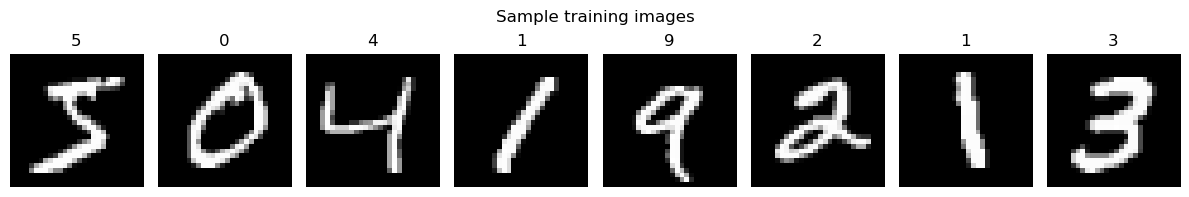

In [3]:
def preprocess(images, labels):
    X = images.astype(np.float32) / 255.0
    X = X[:, :, :, np.newaxis]                        # (N, 28, 28, 1)
    Y = np.zeros((len(labels), 10), dtype=np.float32)
    Y[np.arange(len(labels)), labels] = 1.0           # one-hot
    return X, Y

X_train, Y_train = preprocess(train_images, train_labels)
X_val,   Y_val   = preprocess(test_images,  test_labels)
L_val = test_labels   # raw integer labels for accuracy check

print(f"X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"X_val  : {X_val.shape}    Y_val  : {Y_val.shape}")

# Show a few samples
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_train[i, :, :, 0], cmap='gray')
    ax.set_title(str(train_labels[i]))
    ax.axis('off')
plt.suptitle("Sample training images")
plt.tight_layout()
plt.show()

STEP 3: TRAIN / VALIDATION SPLIT

In [4]:
np.random.seed(42)

def he(shape):
    """He initialization: std = sqrt(2 / fan_in)"""
    fan_in = np.prod(shape[:-1])
    return np.random.randn(*shape).astype(np.float32) * np.sqrt(2.0 / fan_in)

# Weights
W1 = he((3, 3,    1,  32))  # Conv1: 32 filters of 3×3, 1 input channel
b1 = np.zeros(32,  dtype=np.float32)
W2 = he((3, 3,   32,  64))  # Conv2: 64 filters of 3×3, 32 input channels
b2 = np.zeros(64,  dtype=np.float32)
W3 = he((1600, 256))        # Dense: flatten(5×5×64=1600) → 256
b3 = np.zeros(256, dtype=np.float32)
W4 = he((256,  10))         # Dense: 256 → 10 classes
b4 = np.zeros(10,  dtype=np.float32)

# Momentum velocity buffers (start at zero)
vW1=np.zeros_like(W1); vb1=np.zeros_like(b1)
vW2=np.zeros_like(W2); vb2=np.zeros_like(b2)
vW3=np.zeros_like(W3); vb3=np.zeros_like(b3)
vW4=np.zeros_like(W4); vb4=np.zeros_like(b4)

print("Weights initialized (He init):")
for name, w in [("W1",W1),("W2",W2),("W3",W3),("W4",W4)]:
    print(f"  {name}: {w.shape}  std={w.std():.4f}")

Weights initialized (He init):
  W1: (3, 3, 1, 32)  std=0.4691
  W2: (3, 3, 32, 64)  std=0.0835
  W3: (1600, 256)  std=0.0354
  W4: (256, 10)  std=0.0880


STEP 4: INITIALIZE CNN WEIGHTS

In [5]:
# ── im2col / col2im ────────────────────────────────────────────────────────────

def im2col(X, kH, kW):
    """
    Rearrange image patches into columns.
    X   : (N, H, W, C)
    out : (N*oH*oW,  kH*kW*C)
    """
    N, H, W, C = X.shape
    oH, oW = H - kH + 1, W - kW + 1
    col = np.zeros((N, oH, oW, kH, kW, C), dtype=np.float32)
    for i in range(kH):
        for j in range(kW):
            col[:, :, :, i, j, :] = X[:, i:i+oH, j:j+oW, :]
    return col.reshape(N * oH * oW, kH * kW * C)

def col2im(dCol, X_shape, kH, kW):
    """
    Reverse of im2col — accumulate column gradients back into image shape.
    dCol    : (N*oH*oW, kH*kW*C)
    X_shape : (N, H, W, C)
    """
    N, H, W, C = X_shape
    oH, oW = H - kH + 1, W - kW + 1
    dCol_r = dCol.reshape(N, oH, oW, kH, kW, C)
    dX = np.zeros(X_shape, dtype=np.float32)
    for i in range(kH):
        for j in range(kW):
            dX[:, i:i+oH, j:j+oW, :] += dCol_r[:, :, :, i, j, :]
    return dX



def conv_forward(X, W, b):
    """
    Vectorized conv: one matrix multiply replaces the triple Python loop.
    X : (N, H, W, C_in)
    W : (kH, kW, C_in, F)
    → (N, oH, oW, F)
    """
    N, H, Wi, C = X.shape
    kH, kW, _, F = W.shape
    oH, oW = H - kH + 1, Wi - kW + 1
    col    = im2col(X, kH, kW)          
    W_col  = W.reshape(-1, F)           
    out    = col @ W_col + b           
    return out.reshape(N, oH, oW, F)

def conv_backward(dOut, X, W):
    """
    Vectorized conv backward.
    Returns dX, dW, db.
    """
    N, H, Wi, C = X.shape
    kH, kW, _, F = W.shape
    oH, oW = H - kH + 1, Wi - kW + 1
    dOut_r = dOut.reshape(N * oH * oW, F)    
    col    = im2col(X, kH, kW)                
    W_col  = W.reshape(-1, F)                 
    dW     = (col.T @ dOut_r).reshape(W.shape)
    db     = dOut_r.sum(axis=0)
    dCol   = dOut_r @ W_col.T                 
    dX     = col2im(dCol, X.shape, kH, kW)
    return dX, dW, db



def maxpool_forward(X):
    """2×2 max pooling — fully vectorized."""
    N, H, W, C = X.shape
    oH, oW = H // 2, W // 2
    X_r = X[:, :oH*2, :oW*2, :].reshape(N, oH, 2, oW, 2, C)
    return X_r.max(axis=(2, 4))

def maxpool_backward(dOut, X_in):
    """Gradient flows only through the max element in each 2×2 window."""
    N, H, W, C = X_in.shape
    oH, oW = H // 2, W // 2
    X_r  = X_in[:, :oH*2, :oW*2, :].reshape(N, oH, 2, oW, 2, C)
    mx   = X_r.max(axis=(2, 4), keepdims=True)
    mask = (X_r == mx).astype(np.float32)
    mask /= mask.sum(axis=(2, 4), keepdims=True).clip(min=1)  # handle ties
    dX_r = mask * dOut[:, :, np.newaxis, :, np.newaxis, :]
    dX   = np.zeros_like(X_in)
    dX[:, :oH*2, :oW*2, :] = dX_r.reshape(N, oH*2, oW*2, C)
    return dX



def relu(x):    return np.maximum(0, x)

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

print("All layer functions defined.")

All layer functions defined.


STEP 5: FORWARD PASS (one batch)

In [6]:
DROPOUT_RATE = 0.20   

def forward(X, training=True):
    """
    Full forward pass.
    training=True  → apply dropout  (use during training)
    training=False → no dropout     (use during validation/prediction)

    Returns a cache dict with every intermediate value needed for backprop.
    """

    z1   = conv_forward(X, W1, b1)    # (N, 26, 26, 32)
    a1   = relu(z1)                   # (N, 26, 26, 32)
    p1   = maxpool_forward(a1)        # (N, 13, 13, 32)


    z2   = conv_forward(p1, W2, b2)   # (N, 11, 11, 64)
    a2   = relu(z2)                   # (N, 11, 11, 64)
    p2   = maxpool_forward(a2)        # (N,  5,  5, 64)

    flat = p2.reshape(p2.shape[0], -1)     # (N, 1600)
    z3   = flat @ W3 + b3                  # (N, 256)
    a3   = relu(z3)                        # (N, 256)


    if training:
        mask = (np.random.rand(*a3.shape) > DROPOUT_RATE).astype(np.float32)
        a3d  = a3 * mask / (1.0 - DROPOUT_RATE)
    else:
        mask = np.ones_like(a3)
        a3d  = a3

    z4   = a3d @ W4 + b4                   # (N, 10)
    out  = softmax(z4)                     # (N, 10)

    cache = dict(
        X=X, z1=z1, a1=a1, p1=p1,
        z2=z2, a2=a2, p2=p2,
        flat=flat, z3=z3, a3=a3, mask=mask, a3d=a3d,
        z4=z4, out=out
    )
    return cache

print("Forward pass defined.")

Forward pass defined.


STEP 6: BACKWARD PASS + WEIGHT UPDATE

In [7]:
MOMENTUM = 0.9

def backward_and_update(Y_true, cache, lr):
    global W1, b1, W2, b2, W3, b3, W4, b4
    global vW1, vb1, vW2, vb2, vW3, vb3, vW4, vb4

    X    = cache['X']
    z1   = cache['z1'];  a1  = cache['a1'];  p1   = cache['p1']
    z2   = cache['z2'];  a2  = cache['a2'];  p2   = cache['p2']
    flat = cache['flat']; z3 = cache['z3'];  a3   = cache['a3']
    mask = cache['mask']; a3d= cache['a3d']; out  = cache['out']
    N = X.shape[0]

 
    dZ4  = (out - Y_true) / N            
    dW4  = a3d.T @ dZ4                   
    db4  = dZ4.sum(axis=0)               
    dA3d = dZ4 @ W4.T                   

 
    dA3  = dA3d * mask / (1.0 - DROPOUT_RATE)

    dZ3  = dA3 * (z3 > 0)                
    dW3  = flat.T @ dZ3                  
    db3  = dZ3.sum(axis=0)              
    dFlat= dZ3 @ W3.T                  

    dP2  = dFlat.reshape(p2.shape)       

    
    dA2  = maxpool_backward(dP2, a2)    # (N, 11, 11, 64)

 
    dZ2  = dA2 * (z2 > 0)               # ReLU gate
    dP1, dW2_g, db2_g = conv_backward(dZ2, p1, W2)

 ─
    dA1  = maxpool_backward(dP1, a1)    # (N, 26, 26, 32)


    dZ1  = dA1 * (z1 > 0)               # ReLU gate
    _, dW1_g, db1_g = conv_backward(dZ1, X, W1)


    def update(W, b, dW, db, vW, vb):
        vW[:] = MOMENTUM * vW + dW
        vb[:] = MOMENTUM * vb + db
        W -= lr * vW
        b -= lr * vb

    update(W1, b1, dW1_g, db1_g, vW1, vb1)
    update(W2, b2, dW2_g, db2_g, vW2, vb2)
    update(W3, b3, dW3,   db3,   vW3, vb3)
    update(W4, b4, dW4,   db4,   vW4, vb4)

print("Backward pass with momentum defined.")

Backward pass with momentum defined.


STEP 7: TRAINING LOOP

In [9]:
EPOCHS   = 15
BATCH    = 128
LR_MAX   = 0.005
LR_MIN   = 0.0005

loss_history    = []
val_acc_history = []

print("=" * 58)
print("TRAINING  — pure NumPy CNN")
print("=" * 58)
print(f"{'Epoch':<7} {'LR':>9} {'Train Loss':>12} {'Val Acc':>10}")
print("-" * 43)

for epoch in range(EPOCHS):

    t  = epoch / max(EPOCHS - 1, 1)
    lr = LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + np.cos(np.pi * t))

    # Shuffle
    idx    = np.random.permutation(len(X_train))
    Xs, Ys = X_train[idx], Y_train[idx]

    total_loss, n_batches = 0.0, 0

    for start in range(0, len(X_train), BATCH):
        Xb = Xs[start:start+BATCH]
        Yb = Ys[start:start+BATCH]

        cache = forward(Xb, training=True)
        out   = cache['out']

        # Cross-entropy loss
        loss = -np.sum(Yb * np.log(out + 1e-9)) / len(Xb)
        total_loss += loss
        n_batches  += 1

        backward_and_update(Yb, cache, lr)

    avg_loss = total_loss / n_batches
    loss_history.append(avg_loss)

    # Validation accuracy (no dropout)
    preds_epoch = []
    for s in range(0, len(X_val), 256):
        c = forward(X_val[s:s+256], training=False)
        preds_epoch.extend(np.argmax(c['out'], axis=1))
    val_acc = np.mean(np.array(preds_epoch) == L_val)
    val_acc_history.append(val_acc)

    print(f"  {epoch+1:<5} {lr:>9.5f} {avg_loss:>12.4f} {val_acc*100:>9.2f}%")

print("-" * 43)
best_epoch = np.argmax(val_acc_history) + 1
print(f"\nBest Val Accuracy: {max(val_acc_history)*100:.2f}%  (Epoch {best_epoch})")
preds = np.array(preds_epoch)   # final epoch predictions

TRAINING  — pure NumPy CNN
Epoch          LR   Train Loss    Val Acc
-------------------------------------------
  1       0.00500       0.1599     97.72%
  2       0.00494       0.0931     98.09%
  3       0.00478       0.0702     98.53%
  4       0.00451       0.0589     98.49%
  5       0.00415       0.0505     98.77%
  6       0.00373       0.0445     98.74%
  7       0.00325       0.0401     98.97%
  8       0.00275       0.0352     99.01%
  9       0.00225       0.0338     99.04%
  10      0.00177       0.0313     99.09%
  11      0.00135       0.0293     99.07%
  12      0.00099       0.0279     99.10%
  13      0.00072       0.0262     99.15%
  14      0.00056       0.0259     99.10%
  15      0.00050       0.0261     99.13%
-------------------------------------------

Best Val Accuracy: 99.15%  (Epoch 13)


STEP 9: PERFORMANCE METRICS

In [10]:
accuracy = np.mean(preds == L_val)

print("\n" + "=" * 60)
print("PER-CLASS METRICS")
print("=" * 60)
print(f"{'Digit':<8} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
print("-" * 42)

all_f1 = []
for cls in range(10):
    TP = np.sum((preds == cls) & (L_val == cls))
    FP = np.sum((preds == cls) & (L_val != cls))
    FN = np.sum((preds != cls) & (L_val == cls))
    P  = TP / (TP + FP + 1e-9)
    R  = TP / (TP + FN + 1e-9)
    F1 = 2 * P * R / (P + R + 1e-9)
    all_f1.append(F1)
    print(f"  {cls:<6}   {P:>10.3f} {R:>10.3f} {F1:>10.3f}")

print("-" * 42)
print(f"  {'Avg':<6}   {'':>10} {'':>10} {np.mean(all_f1):>10.3f}")
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")

# Confusion Matrix
conf = np.zeros((10, 10), dtype=int)
for t, p in zip(L_val, preds):
    conf[t][p] += 1

print("\nConfusion Matrix (rows=True label, cols=Predicted):")
print("     " + "  ".join(f"{i:3}" for i in range(10)))
print("    " + "-" * 40)
for i in range(10):
    print(f"  {i} |" + "  ".join(f"{v:3}" for v in conf[i]))


PER-CLASS METRICS
Digit     Precision     Recall   F1 Score
------------------------------------------
  0             0.984      0.998      0.991
  1             0.994      0.997      0.996
  2             0.992      0.992      0.992
  3             0.992      0.989      0.991
  4             0.994      0.995      0.994
  5             0.990      0.988      0.989
  6             0.997      0.984      0.991
  7             0.984      0.995      0.989
  8             0.993      0.987      0.990
  9             0.994      0.986      0.990
------------------------------------------
  Avg                                 0.991

Overall Accuracy: 99.13%

Confusion Matrix (rows=True label, cols=Predicted):
       0    1    2    3    4    5    6    7    8    9
    ----------------------------------------
  0 |978    1    0    0    0    0    0    1    0    0
  1 |  0  1132    1    0    0    0    1    1    0    0
  2 |  1    1  1024    0    0    0    0    5    1    0
  3 |  0    0    2  999    

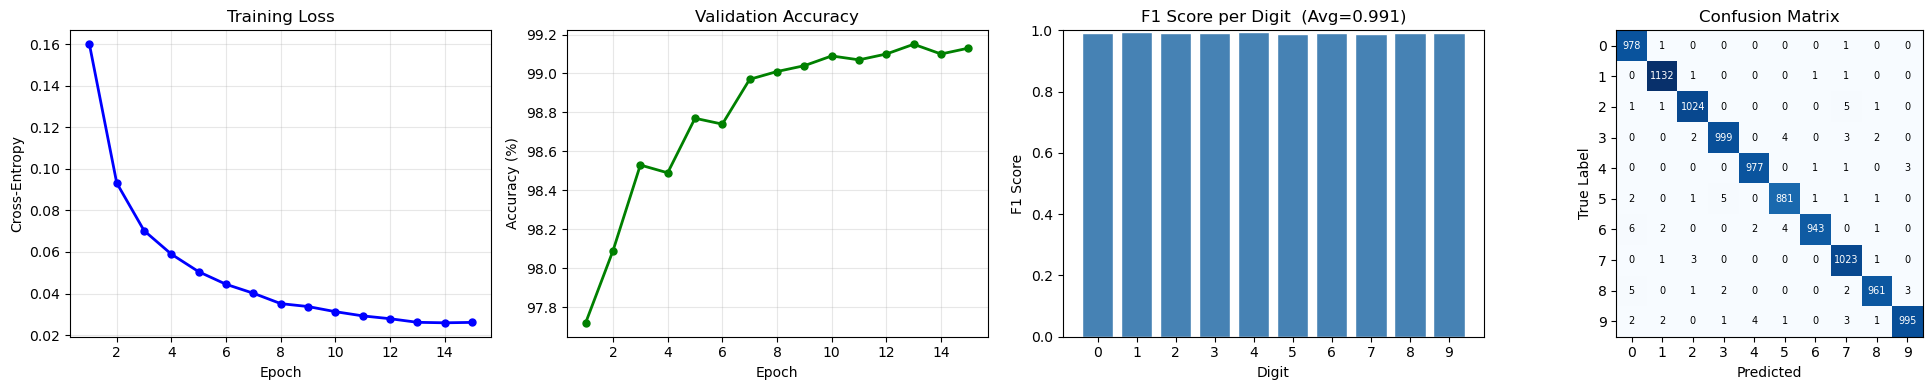

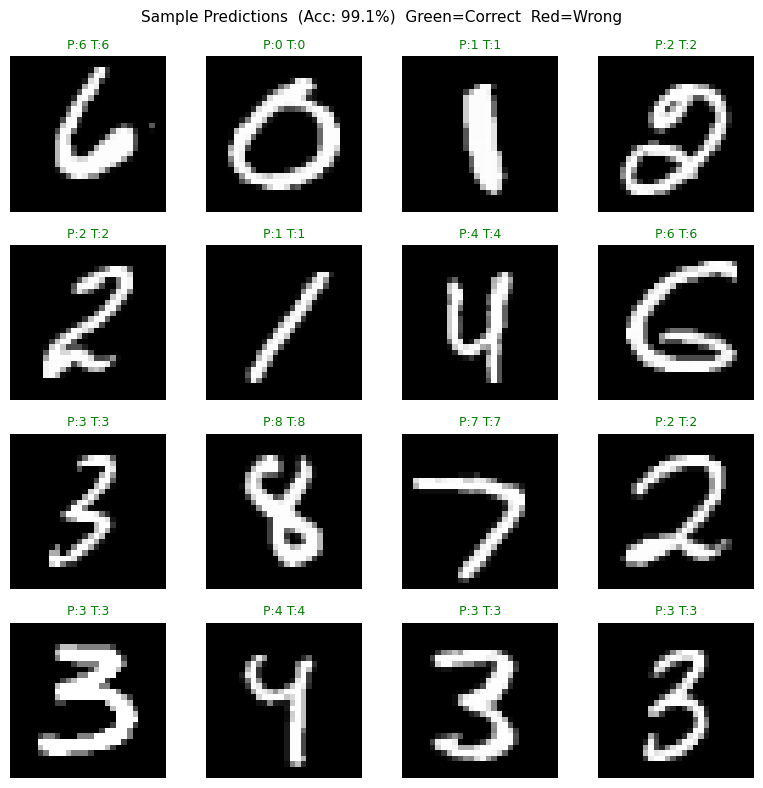

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# 1: Training loss curve
axes[0].plot(range(1, EPOCHS+1), loss_history, 'b-o', linewidth=2, markersize=5)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy")
axes[0].grid(True, alpha=0.3)

# 2: Val accuracy per epoch
axes[1].plot(range(1, EPOCHS+1), [v*100 for v in val_acc_history],
             'g-o', linewidth=2, markersize=5)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, alpha=0.3)

# 3: F1 per digit
axes[2].bar(range(10), all_f1, color='steelblue', edgecolor='white')
axes[2].set_title(f"F1 Score per Digit  (Avg={np.mean(all_f1):.3f})")
axes[2].set_xlabel("Digit")
axes[2].set_ylabel("F1 Score")
axes[2].set_ylim(0, 1.0)
axes[2].set_xticks(range(10))

# 4: Confusion matrix heatmap
axes[3].imshow(conf, cmap='Blues')
axes[3].set_title("Confusion Matrix")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("True Label")
axes[3].set_xticks(range(10))
axes[3].set_yticks(range(10))
thresh = conf.max() // 2
for i in range(10):
    for j in range(10):
        axes[3].text(j, i, conf[i][j], ha='center', va='center',
                     fontsize=7, color='white' if conf[i][j] > thresh else 'black')

plt.tight_layout()
plt.show()

# Sample predictions grid
fig2, axes2 = plt.subplots(4, 4, figsize=(8, 8))
fig2.suptitle(f'Sample Predictions  (Acc: {accuracy*100:.1f}%)  '
               f'Green=Correct  Red=Wrong', fontsize=11)
for ax, i in zip(axes2.flat, np.random.choice(len(X_val), 16, replace=False)):
    ax.imshow(X_val[i, :, :, 0], cmap='gray')
    pred, true = preds[i], L_val[i]
    ax.set_title(f'P:{pred} T:{true}',
                 color='green' if pred == true else 'red', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()